## Bài 7 (Trang 27 - 31)

In [ ]:
#Cell 1 load import load dữ liệu
%matplotlib inline
import matplotlib
import matplotlib.pyplot as plt
from sklearn import datasets, tree, metrics
from sklearn.model_selection import train_test_split

digits = datasets.load_digits()

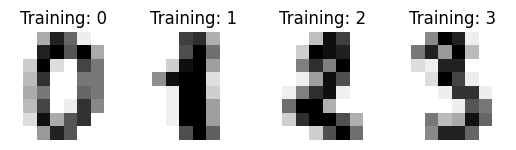

Nguyễn Trung Tín - 6351071070


In [2]:
## Cell 2: Trực quan hóa 4 mẫu dữ liệu đầu tiên
_, axes = plt.subplots(1, 4)
images_and_labels = list(zip(digits.images, digits.target))
for ax, (image, label) in zip(axes, images_and_labels[:4]):
    ax.set_axis_off()
    ax.imshow(image, cmap=plt.cm.gray_r, interpolation='nearest')
    ax.set_title('Training: %i' % label)
plt.show()

print("Nguyễn Trung Tín - 6351071070")

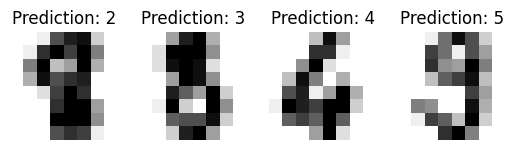

Nguyễn Trung Tín - 6351071070


In [ ]:
# Cell 3: Chuẩn bị dữ liệu (Làm phẳng ảnh)
n_samples = len(digits.images)
data = digits.images.reshape((n_samples, -1))

##Cell 4: Khởi tạo mô hình (Cây quyết định ID3)
classifier = tree.DecisionTreeClassifier(criterion="entropy", random_state=33)

##Cell 5: Chia dữ liệu (Train/Test)
X_train, X_test, y_train, y_test = train_test_split(
    data, digits.target, test_size=0.2, shuffle=False)

## Cell 6: Huấn luyện mô hình
classifier.fit(X_train, y_train)

## Cell 7: Dự đoán trên tập kiểm thử
predicted = classifier.predict(X_test)

## Cell 8: Trực quan hóa kết quả dự đoán
_, axes = plt.subplots(1, 4)
images_and_predictions = list(zip(digits.images[n_samples // 2:], predicted))
for ax, (image, prediction) in zip(axes, images_and_predictions[:4]):
    ax.set_axis_off()
    ax.imshow(image, cmap=plt.cm.gray_r, interpolation='nearest')
    ax.set_title('Prediction: %i' % prediction)
plt.show()

print("Nguyễn Trung Tín - 6351071070")

Classification report for classifier DecisionTreeClassifier(criterion='entropy', random_state=33):
              precision    recall  f1-score   support

           0       0.86      0.89      0.87        35
           1       0.72      0.64      0.68        36
           2       0.76      0.74      0.75        35
           3       0.69      0.59      0.64        37
           4       0.86      0.84      0.85        37
           5       0.80      0.95      0.86        37
           6       0.97      0.95      0.96        37
           7       0.78      0.86      0.82        36
           8       0.79      0.82      0.81        33
           9       0.72      0.70      0.71        37

    accuracy                           0.80       360
   macro avg       0.80      0.80      0.79       360
weighted avg       0.80      0.80      0.79       360


Confusion matrix:
[[31  0  0  0  1  0  0  0  1  2]
 [ 0 23  0  2  2  0  0  1  1  7]
 [ 1  2 26  0  0  1  0  3  2  0]
 [ 0  4  2 22  0  4  0  

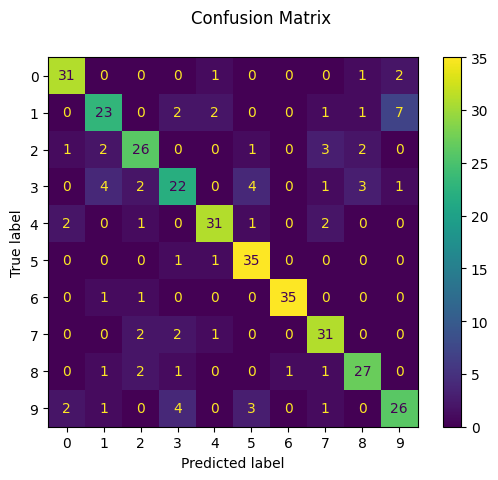

Nguyễn Trung Tín - 6351071070


In [ ]:
##Cell 9: Đánh giá mô hình
print("Classification report for classifier %s:\n%s\n"
      % (classifier, metrics.classification_report(y_test, predicted)))

disp = metrics.ConfusionMatrixDisplay.from_estimator(classifier, X_test, y_test)
disp.figure_.suptitle("Confusion Matrix")
print("Confusion matrix:\n%s" % disp.confusion_matrix)

plt.show()

print("Nguyễn Trung Tín - 6351071070")

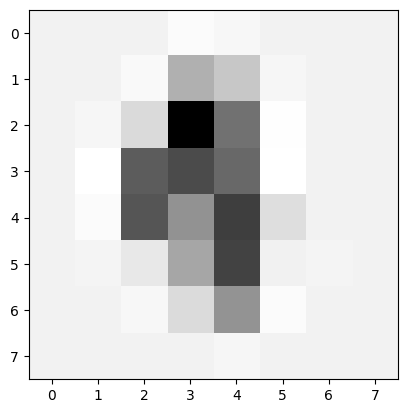

Nguyễn Trung Tín - 6351071070


In [ ]:
##Cell 10: Đọc và xử lý ảnh tùy chỉnh
from PIL import Image, ImageOps
import numpy as np

img = Image.open('so3.jpg').convert("L").resize((8,8))
img = ImageOps.invert(img)
imgarr = np.array(img)

plt.imshow(imgarr, cmap=plt.cm.gray_r, interpolation='nearest')
plt.show()

print("Nguyễn Trung Tín - 6351071070")

[[  0   0   0   0   0   0   0   0   0   0   0   0   0   0   0   0   0   0
    0 155   0   0   0   0   0   0   0 155   0   0   0   0   0   0   0   0
  155   0   0   0   0   0   0   0 155   0   0   0   0   0   0   0   0   0
    0   0   0   0   0   0   0   0   0   0]]


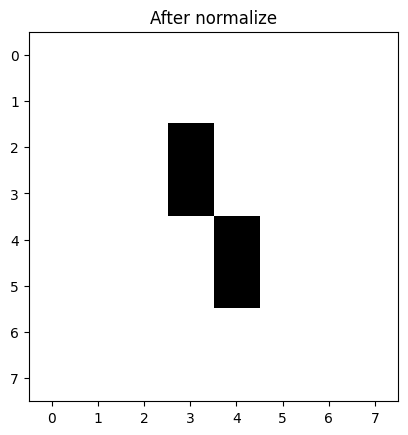

Nguyễn Trung Tín - 6351071070


In [ ]:
##Cell 11: Chuẩn hóa ảnh tùy chỉnh
img1d = imgarr.reshape((1, 64))


img1d[img1d > 109] = 155  # Đặt giá trị lớn hơn 109 thành 155 (trắng)
img1d[img1d < 110] = 0   # Đặt giá trị nhỏ hơn 110 thành 0 (đen)

print(img1d)

# Hiển thị ảnh sau khi chuẩn hóa (reshape lại 8x8 để xem)
img2arr_normalized = img1d.reshape((8, 8))
plt.imshow(img2arr_normalized, cmap=plt.cm.gray_r, interpolation='nearest')
plt.title("After normalize")
plt.show()

print("Nguyễn Trung Tín - 6351071070")

In [ ]:
##Cell 12: Dự đoán ảnh tùy chỉnh
y_pred = classifier.predict(img1d)

print("Kết quả dự đoán:", y_pred)

print("Nguyễn Trung Tín - 6351071070")

Kết quả dự đoán: [1]
Nguyễn Trung Tín - 6351071070


## Bài 2 (Trang 32)

In [ ]:
# Cell 1: BÀI TẬP 1 - Tính F-measure từ Precision và Recall
import matplotlib.pyplot as plt

print("Nguyễn Trung Tín - 6351071070")

print("="*60)
print("BÀI TẬP 1: TÍNH F-MEASURE TỪ PRECISION VÀ RECALL")
print("="*60)

# Ví dụ 1: Tính F-measure từ Precision và Recall có sẵn
precision = 0.8  # 80%
recall = 0.6     # 60%

f_measure = (2 * precision * recall) / (precision + recall)
print(f"\nCho trước:")
print(f"  Precision: {precision} (80%)")
print(f"  Recall: {recall} (60%)")
print(f"\nÁp dụng công thức:")
print(f"  F-measure = 2 × P × R / (P + R)")
print(f"  F-measure = 2 × {precision} × {recall} / ({precision} + {recall})")
print(f"  F-measure = {f_measure:.4f} ({f_measure*100:.2f}%)")


Nguyễn Trung Tín - 6351071070
BÀI TẬP 1: TÍNH F-MEASURE TỪ PRECISION VÀ RECALL

Cho trước:
  Precision: 0.8 (80%)
  Recall: 0.6 (60%)

Áp dụng công thức:
  F-measure = 2 × P × R / (P + R)
  F-measure = 2 × 0.8 × 0.6 / (0.8 + 0.6)
  F-measure = 0.6857 (68.57%)


Nguyễn Trung Tín - 6351071070

BÀI TẬP 2: TÍNH TỪ CONFUSION MATRIX

Confusion Matrix:
  TP: 80, FP: 20, FN: 40, TN: 60

Tính toán:
  Precision = 0.8000
  Recall = 0.6667
  F-measure = 0.7273


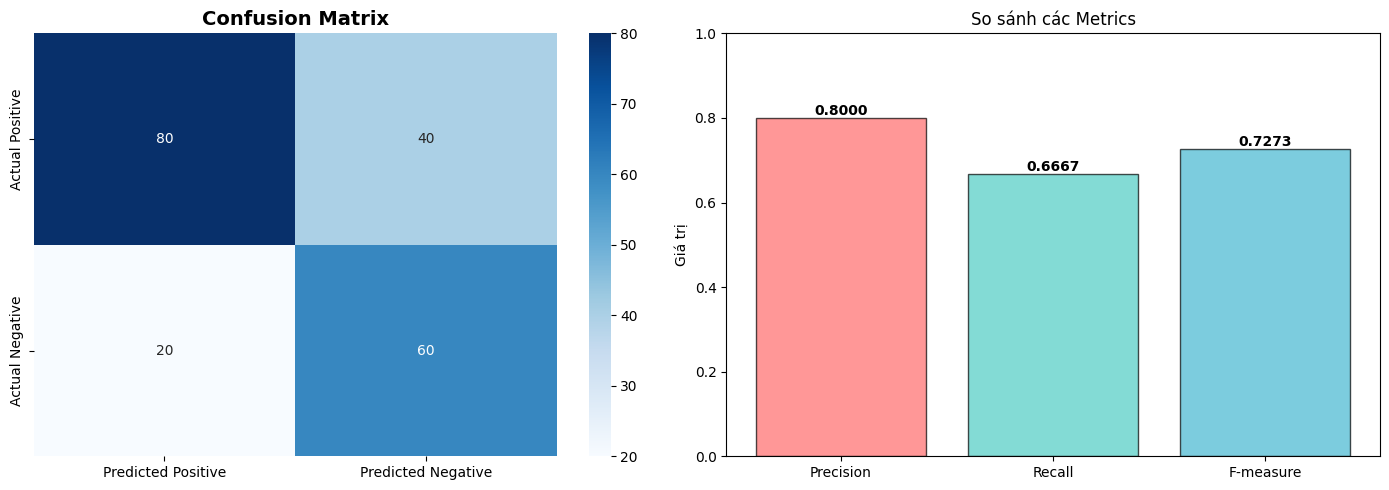

In [2]:
# Cell 2: BÀI TẬP 2 - Tính từ Confusion Matrix
import numpy as np
import seaborn as sns
print("Nguyễn Trung Tín - 6351071070")

print("\n" + "="*60)
print("BÀI TẬP 2: TÍNH TỪ CONFUSION MATRIX")
print("="*60)

# Ví dụ 2: Tính từ Confusion Matrix
TP = 80
FP = 20
FN = 40
TN = 60

precision_calc = TP / (TP + FP) if (TP + FP) > 0 else 0
recall_calc = TP / (TP + FN) if (TP + FN) > 0 else 0
f_measure_calc = (2 * precision_calc * recall_calc) / (precision_calc + recall_calc) if (precision_calc + recall_calc) > 0 else 0

print(f"\nConfusion Matrix:")
print(f"  TP: {TP}, FP: {FP}, FN: {FN}, TN: {TN}")
print(f"\nTính toán:")
print(f"  Precision = {precision_calc:.4f}")
print(f"  Recall = {recall_calc:.4f}")
print(f"  F-measure = {f_measure_calc:.4f}")

# Vẽ Confusion Matrix và Bar chart
fig, ax = plt.subplots(1, 2, figsize=(14, 5))

cm_data = np.array([[TP, FN], [FP, TN]])
sns.heatmap(cm_data, annot=True, fmt='d', cmap='Blues', ax=ax[0],
            xticklabels=['Predicted Positive', 'Predicted Negative'],
            yticklabels=['Actual Positive', 'Actual Negative'])
ax[0].set_title('Confusion Matrix', fontsize=14, fontweight='bold')

metrics = ['Precision', 'Recall', 'F-measure']
values = [precision_calc, recall_calc, f_measure_calc]
colors = ['#FF6B6B', '#4ECDC4', '#45B7D1']
bars = ax[1].bar(metrics, values, color=colors, alpha=0.7, edgecolor='black')
ax[1].set_ylim(0, 1)
ax[1].set_ylabel('Giá trị')
ax[1].set_title('So sánh các Metrics')
for bar, value in zip(bars, values):
    ax[1].text(bar.get_x() + bar.get_width()/2., value, f'{value:.4f}', ha='center', va='bottom', fontweight='bold')

plt.tight_layout()
plt.show()


In [3]:
# Cell 3: BÀI TẬP 3 - Ví dụ thực tế (dự đoán bệnh)
from sklearn.metrics import precision_score, recall_score, f1_score, confusion_matrix
print("Nguyễn Trung Tín - 6351071070")

print("\n" + "="*60)
print("BÀI TẬP 3: VÍ DỤ THỰC TÊ - DỰ ĐOÁN BỆNH")
print("="*60)

y_true = [1, 1, 0, 1, 0, 1, 0, 0, 1, 1, 1, 0, 1, 0, 0]
y_pred = [1, 0, 0, 1, 0, 1, 1, 0, 1, 0, 1, 0, 1, 1, 0]

precision_sklearn = precision_score(y_true, y_pred)
recall_sklearn = recall_score(y_true, y_pred)
f1_sklearn = f1_score(y_true, y_pred)

print(f"Precision: {precision_sklearn:.4f}")
print(f"Recall: {recall_sklearn:.4f}")
print(f"F1-score: {f1_sklearn:.4f}")

cm = confusion_matrix(y_true, y_pred)
print(f"\nConfusion Matrix chi tiết:")
print(f"  TP: {cm[1,1]}, FP: {cm[0,1]}, FN: {cm[1,0]}, TN: {cm[0,0]}")


Nguyễn Trung Tín - 6351071070

BÀI TẬP 3: VÍ DỤ THỰC TÊ - DỰ ĐOÁN BỆNH
Precision: 0.7500
Recall: 0.7500
F1-score: 0.7500

Confusion Matrix chi tiết:
  TP: 6, FP: 2, FN: 2, TN: 5


Nguyễn Trung Tín - 6351071070

BÀI TẬP 4: SO SÁNH NHIỀU MÔ HÌNH

Model        Precision    Recall       F-measure   
------------------------------------------------
Model A      0.8500       0.7000       0.7677      
Model B      0.7500       0.8500       0.7969      
Model C      0.9000       0.6500       0.7548      


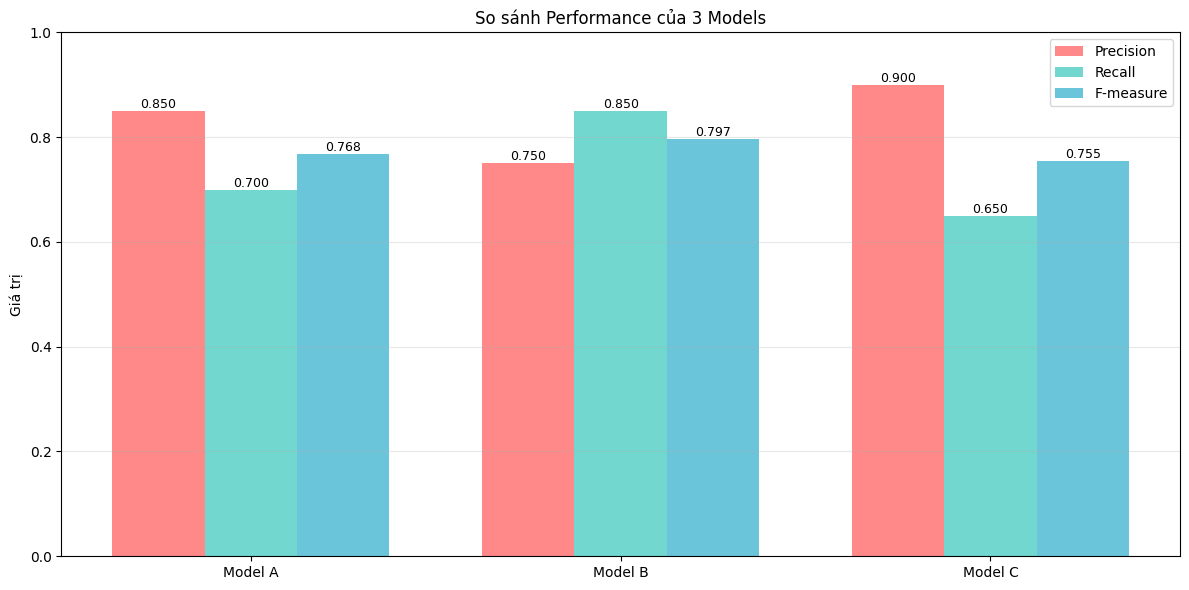


Kết luận: Model C có Precision cao nhất nhưng F-measure không cao nhất.
          Model B cân bằng hơn với F-measure = 0.7969


In [4]:
# Cell 4: BÀI TẬP 4 - So sánh nhiều mô hình
print("Nguyễn Trung Tín - 6351071070")

print("\n" + "="*60)
print("BÀI TẬP 4: SO SÁNH NHIỀU MÔ HÌNH")
print("="*60)

models = ['Model A', 'Model B', 'Model C']
precisions = [0.85, 0.75, 0.90]
recalls = [0.70, 0.85, 0.65]
f_measures = [(2*p*r)/(p+r) for p,r in zip(precisions, recalls)]

# Bảng so sánh
print(f"\n{'Model':<12} {'Precision':<12} {'Recall':<12} {'F-measure':<12}")
print("-"*48)
for m,p,r,f in zip(models, precisions, recalls, f_measures):
    print(f"{m:<12} {p:<12.4f} {r:<12.4f} {f:<12.4f}")

# Biểu đồ so sánh
x = np.arange(len(models))
width = 0.25
fig, ax = plt.subplots(figsize=(12,6))

bars1 = ax.bar(x - width, precisions, width, label='Precision', color='#FF6B6B', alpha=0.8)
bars2 = ax.bar(x, recalls, width, label='Recall', color='#4ECDC4', alpha=0.8)
bars3 = ax.bar(x + width, f_measures, width, label='F-measure', color='#45B7D1', alpha=0.8)

ax.set_ylabel('Giá trị')
ax.set_title('So sánh Performance của 3 Models')
ax.set_xticks(x)
ax.set_xticklabels(models)
ax.legend()
ax.set_ylim(0,1)
ax.grid(axis='y', alpha=0.3)

for bars in [bars1, bars2, bars3]:
    for bar in bars:
        height = bar.get_height()
        ax.text(bar.get_x() + bar.get_width()/2., height, f'{height:.3f}', ha='center', va='bottom', fontsize=9)

plt.tight_layout()
plt.show()

print(f"\nKết luận: Model C có Precision cao nhất nhưng F-measure không cao nhất.")
print(f"          Model B cân bằng hơn với F-measure = {f_measures[1]:.4f}")


In [5]:
# Cell 5: TỔNG KẾT
print("Nguyễn Trung Tín - 6351071070")

print("\n" + "="*60)
print("TỔNG KẾT")
print("="*60)
print("✓ F-measure giúp cân bằng giữa Precision và Recall")
print("✓ F-measure cao khi cả Precision và Recall đều cao")
print("✓ Sử dụng F-measure để so sánh các mô hình khác nhau")
print("="*60)


Nguyễn Trung Tín - 6351071070

TỔNG KẾT
✓ F-measure giúp cân bằng giữa Precision và Recall
✓ F-measure cao khi cả Precision và Recall đều cao
✓ Sử dụng F-measure để so sánh các mô hình khác nhau
